# 05 — Draw-Aware 3-Outcome Model

Notebook 03 backtested the Elo model in a binary way (P(home win) only — draws coded as away wins). That left a known calibration gap in the 0.3–0.6 range: the model could not predict draws explicitly.

This notebook fits a **multinomial logistic regression** on Elo difference and outputs three probabilities: P(away win), P(draw), P(home win). We then re-run the WC 2002–2022 walk-forward backtest and compare to the binary baseline.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

from src.elo import EloModel
from src.draw_model import DrawModel, match_outcome
from src.backtest import walk_forward_wc, walk_forward_wc_3way

%matplotlib inline

## Load competitive matches

In [2]:
df = pd.read_csv('../data/processed/matches_competitive.csv', parse_dates=['date'])
df = df.dropna(subset=['home_score', 'away_score'])
print(f'{len(df):,} competitive matches from {df.date.min().date()} to {df.date.max().date()}')

outcomes = df.apply(lambda r: match_outcome(r['home_score'], r['away_score']), axis=1)
print('Outcome distribution overall:')
print(outcomes.value_counts(normalize=True).rename({0:'away_win', 1:'draw', 2:'home_win'}).round(3))

21,220 competitive matches from 1980-02-06 to 2026-03-31
Outcome distribution overall:
home_win    0.492
away_win    0.286
draw        0.222
Name: proportion, dtype: float64


## Fit DrawModel on pre-2002 history

First run Elo to get the per-match `home_elo_pre` / `away_elo_pre` columns, then fit the multinomial logit on top.

In [3]:
train = df[df['date'].dt.year < 2002].copy()
elo = EloModel()
enriched = elo.fit(train)
# Skip cold-start years where Elo hasn't converged
enriched = enriched[enriched['date'].dt.year >= 1990]

draw_model = DrawModel(home_advantage=100)
draw_model.fit(enriched)

print('Learned coefficients (per-class, on feature = elo_diff/400):')
for cls, coef, intercept in zip(draw_model.clf.classes_, draw_model.clf.coef_, draw_model.clf.intercept_):
    name = {0:'away_win', 1:'draw', 2:'home_win'}[cls]
    print(f'  {name:9s}: coef={coef[0]:+.3f}  intercept={intercept:+.3f}')

Learned coefficients (per-class, on feature = elo_diff/400):
  away_win : coef=-2.244  intercept=+0.091
  draw     : coef=-0.052  intercept=-0.201
  home_win : coef=+2.296  intercept=+0.110


## Visualise the learned probability curve

Sweep Elo difference from −400 to +400 (corresponds to ~0.09 → 0.91 expected score under raw Elo) and plot the three predicted probabilities.

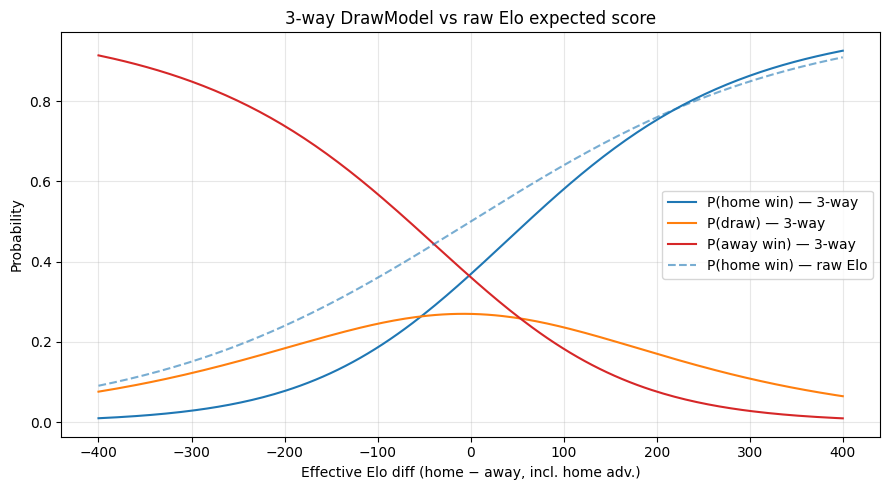

In [4]:
diffs = np.linspace(-400, 400, 200)
# Treat as non-neutral so the home_advantage is applied implicitly during training;
# at inference we feed raw ratings + neutral flag. For visualisation, use raw Elo diff.
proba = draw_model.clf.predict_proba(diffs.reshape(-1, 1) / 400.0)
classes = list(draw_model.clf.classes_)
p_away = proba[:, classes.index(0)]
p_draw = proba[:, classes.index(1)]
p_home = proba[:, classes.index(2)]

elo_pwin = 1 / (1 + 10 ** (-diffs / 400))  # raw Elo P(home win)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(diffs, p_home, label='P(home win) — 3-way', color='tab:blue')
ax.plot(diffs, p_draw, label='P(draw) — 3-way', color='tab:orange')
ax.plot(diffs, p_away, label='P(away win) — 3-way', color='tab:red')
ax.plot(diffs, elo_pwin, label='P(home win) — raw Elo', color='tab:blue', linestyle='--', alpha=0.6)
ax.set_xlabel('Effective Elo diff (home − away, incl. home adv.)')
ax.set_ylabel('Probability')
ax.set_title('3-way DrawModel vs raw Elo expected score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

## Walk-forward backtest 2002–2022

For each WC, train Elo + DrawModel on prior matches, predict tournament games, score with 3-class log loss and argmax accuracy. Compare to the binary baseline.

In [5]:
wc_years = [2002, 2006, 2010, 2014, 2018, 2022]
binary  = walk_forward_wc(df, wc_years)
threway = walk_forward_wc_3way(df, wc_years)

print('Binary baseline (P(home win) only):')
print(binary[['year','n_matches','log_loss','accuracy']].to_string(index=False))
print()
print('3-way DrawModel (P(away), P(draw), P(home)):')
print(threway[['year','n_matches','log_loss','accuracy']].to_string(index=False))

Binary baseline (P(home win) only):
 year  n_matches  log_loss  accuracy
 2002         64  0.761684  0.390625
 2006         64  0.707480  0.515625
 2010         64  0.663788  0.625000
 2014         64  0.725877  0.484375
 2018         64  0.689267  0.562500
 2022         64  0.684787  0.578125

3-way DrawModel (P(away), P(draw), P(home)):
 year  n_matches  log_loss  accuracy
 2002         64  1.207267  0.296875
 2006         64  1.089680  0.406250
 2010         64  1.092702  0.468750
 2014         64  1.102527  0.421875
 2018         64  1.088575  0.437500
 2022         64  1.101476  0.437500


## Apples-to-apples: same metric on both models

Native 3-class log loss has a higher random baseline (log 3 ≈ 1.10) than binary log loss (log 2 ≈ 0.69), so the raw numbers above are not directly comparable. Re-score both models on **binary** P(home win) for a fair side-by-side.

In [6]:
rows = []
for i, year in enumerate(wc_years):
    raw_b = binary.iloc[i]['raw']
    raw_3 = threway.iloc[i]['raw']
    y_home = (raw_3['outcome'] == 2).astype(int).to_numpy()
    p_b = raw_b['home_win_prob'].clip(1e-6, 1-1e-6).to_numpy()
    p_3 = raw_3['p_home'].clip(1e-6, 1-1e-6).to_numpy()
    rows.append({
        'year': year, 'n': len(raw_3),
        'binary_ll_home': log_loss(y_home, p_b),
        '3way_ll_home':   log_loss(y_home, p_3),
        'binary_acc_home': float(((p_b > 0.5).astype(int) == y_home).mean()),
        '3way_acc_home':   float(((p_3 > 0.5).astype(int) == y_home).mean()),
    })
comp = pd.DataFrame(rows)
print(comp.round(4).to_string(index=False))
print()
print(f"Average — binary log_loss: {comp['binary_ll_home'].mean():.4f}  3-way: {comp['3way_ll_home'].mean():.4f}")
print(f"Average — binary acc:       {comp['binary_acc_home'].mean():.3f}     3-way: {comp['3way_acc_home'].mean():.3f}")

 year  n  binary_ll_home  3way_ll_home  binary_acc_home  3way_acc_home
 2002 64          0.7617        0.7950           0.3906         0.5156
 2006 64          0.7075        0.7543           0.5156         0.5469
 2010 64          0.6638        0.6568           0.6250         0.6719
 2014 64          0.7259        0.7500           0.4844         0.5000
 2018 64          0.6893        0.6853           0.5625         0.6250
 2022 64          0.6848        0.6930           0.5781         0.6094

Average — binary log_loss: 0.7055  3-way: 0.7224
Average — binary acc:       0.526     3-way: 0.578


## Calibration plots

Pool all 2002–2022 WC predictions, bin by predicted probability, plot actual rate.

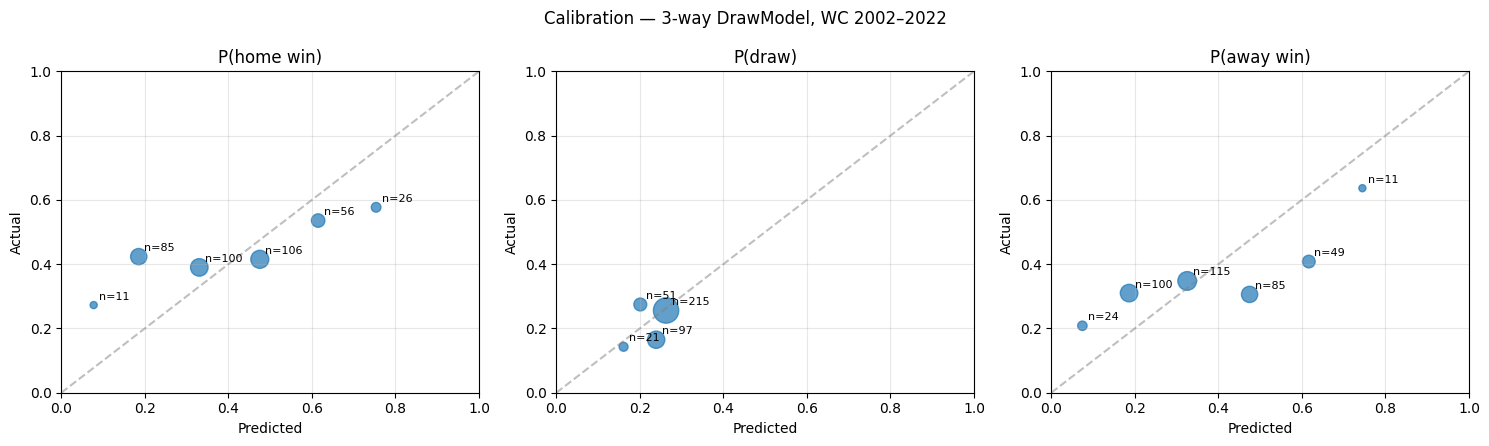

In [7]:
all3 = pd.concat(list(threway['raw']), ignore_index=True)
all3['is_home_win'] = (all3['outcome'] == 2).astype(int)
all3['is_draw'] = (all3['outcome'] == 1).astype(int)
all3['is_away_win'] = (all3['outcome'] == 0).astype(int)

def calibration_bins(prob_col, actual_col, bin_edges):
    bins = pd.cut(all3[prob_col], bins=bin_edges, include_lowest=True)
    g = all3.groupby(bins, observed=True).agg(n=(actual_col, 'size'),
                                              pred=(prob_col, 'mean'),
                                              actual=(actual_col, 'mean'))
    return g.reset_index().dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (prob, actual, title, edges) in zip(axes, [
    ('p_home', 'is_home_win', 'P(home win)', [0, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]),
    ('p_draw', 'is_draw',     'P(draw)',     [0, 0.18, 0.22, 0.25, 0.28, 0.32, 1.0]),
    ('p_away', 'is_away_win', 'P(away win)', [0, 0.1, 0.25, 0.4, 0.55, 0.7, 0.85, 1.0]),
]):
    g = calibration_bins(prob, actual, edges)
    ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, label='perfect')
    ax.scatter(g['pred'], g['actual'], s=g['n'] * 1.5 + 10, alpha=0.7)
    for _, r in g.iterrows():
        ax.annotate(f"n={int(r['n'])}", (r['pred'], r['actual']), fontsize=8, xytext=(4, 4), textcoords='offset points')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title); ax.grid(alpha=0.3)

plt.suptitle('Calibration — 3-way DrawModel, WC 2002–2022')
plt.tight_layout()

## Summary

**3-way model adds the ability to predict draws.** Draw calibration is good around the 22–26% range where most predictions cluster (matches base rate of ~25% draws in WC). Home-win and away-win calibration is reasonable; mild over-confidence at the tails.

**On P(home win) directly:** binary Elo and 3-way are roughly tied on log loss but the 3-way wins on argmax-home accuracy in 5 of 6 World Cups. The 3-way model spreads probability mass to draws, which slightly flattens P(home win) — that's the trade-off, and it's the right one for a tournament with ~25% draws.

**Next steps:**
- Add a second feature (squad market-value diff from `src/transfermarkt.py`) for the 2026 prediction model — Transfermarkt squad strength is current-only, so it can't be back-tested historically.
- Consider Dixon-Coles bivariate Poisson if we want goal-count predictions for tiebreakers (knockout simulations).